# 简单神经网络

## torch包测试

In [5]:
import torch
import torchvision
print('✅ PyTorch 版本:', torch.__version__)
print('✅ torchvision 版本:', torchvision.__version__)
print('✅ CUDA 是否可用:', torch.cuda.is_available())
print('✅ CPU 模式正常工作')

✅ PyTorch 版本: 2.2.2
✅ torchvision 版本: 0.17.2
✅ CUDA 是否可用: False
✅ CPU 模式正常工作


## 简单的线性回归神经网络

In [2]:
import torch.nn as nn
import torch.optim as optim

# 创建一个简单的线性回归神经网络
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)  # 输入1维，输出1维
    
    def forward(self, x):
        return self.fc(x)

# 生成简单数据：y = 2x + 1
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# 训练模型
model = SimpleNet()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

# 测试：输入 x=5，期望输出 11
test_x = torch.tensor([[5.0]])
print(f"预测结果: {model(test_x).item():.2f} (期望: 11.00)")

预测结果: 11.18 (期望: 11.00)


## 使用多层神经网络对鸢尾花数据集进行分类

训练集大小: 105
测试集大小: 45
IrisClassifier(
  (layer1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=10, out_features=3, bias=True)
)
Epoch [20/200], Loss: 0.4513, Train Acc: 0.8381
Epoch [40/200], Loss: 0.2732, Train Acc: 0.9048
Epoch [60/200], Loss: 0.1889, Train Acc: 0.9333
Epoch [80/200], Loss: 0.1232, Train Acc: 0.9714
Epoch [100/200], Loss: 0.0858, Train Acc: 0.9714
Epoch [120/200], Loss: 0.0656, Train Acc: 0.9714
Epoch [140/200], Loss: 0.0537, Train Acc: 0.9810
Epoch [160/200], Loss: 0.0457, Train Acc: 0.9905
Epoch [180/200], Loss: 0.0399, Train Acc: 0.9905
Epoch [200/200], Loss: 0.0356, Train Acc: 0.9905

✅ 测试集准确率: 0.9333 (42/45)


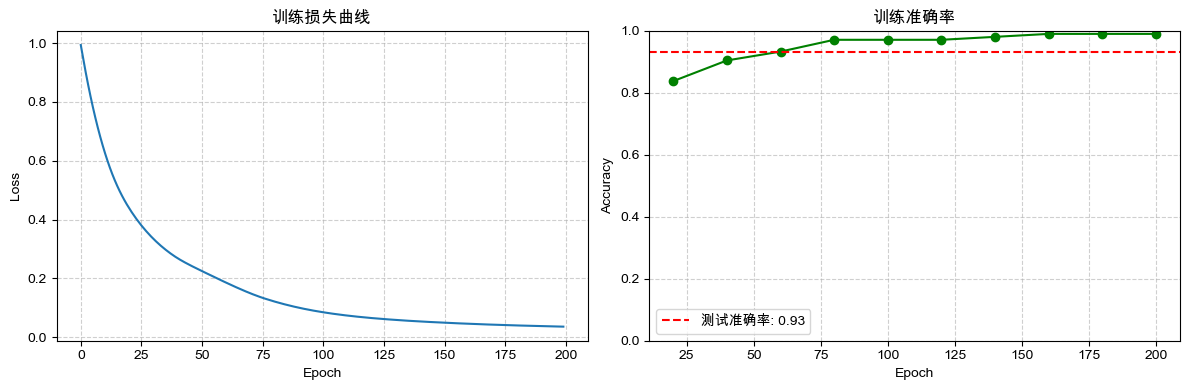


📊 预测示例（测试集前5个样本）:
--------------------------------------------------
样本 1: 预测类别 = 2 (virginica), 真实类别 = 2 (virginica)
样本 2: 预测类别 = 1 (versicolor), 真实类别 = 1 (versicolor)
样本 3: 预测类别 = 1 (versicolor), 真实类别 = 2 (virginica)
样本 4: 预测类别 = 1 (versicolor), 真实类别 = 1 (versicolor)
样本 5: 预测类别 = 2 (virginica), 真实类别 = 2 (virginica)


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 准备数据 ==========
iris = load_iris()
X = iris.data          # 特征: 花萼长度、花萼宽度、花瓣长度、花瓣宽度
y = iris.target        # 标签: 0=Setosa, 1=Versicolor, 2=Virginica

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 标准化特征 (让训练更稳定)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 转换为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")

# ========== 2. 定义神经网络 ==========
class IrisClassifier(nn.Module):
    def __init__(self, input_size=4, hidden_size=10, num_classes=3):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = IrisClassifier()
print(model)

# ========== 3. 定义损失函数和优化器 ==========
criterion = nn.CrossEntropyLoss()   # 多分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ========== 4. 训练模型 ==========
num_epochs = 200
train_losses = []
accuracies = []

for epoch in range(num_epochs):
    # 前向传播
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # 每20轮打印一次训练准确率
    if (epoch + 1) % 20 == 0:
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == y_train).sum().item()
        acc = correct / len(y_train)
        accuracies.append(acc)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

# ========== 5. 测试模型 ==========
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_test).sum().item()
    test_acc = correct / len(y_test)
    print(f"\n✅ 测试集准确率: {test_acc:.4f} ({correct}/{len(y_test)})")

# ========== 6. 可视化训练过程 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses)
axes[0].set_title('训练损失曲线', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 准确率曲线
axes[1].plot(range(20, num_epochs+1, 20), accuracies, 'o-', color='green')
axes[1].set_title('训练准确率', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(y=test_acc, color='red', linestyle='--', label=f'测试准确率: {test_acc:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# ========== 7. 预测示例 ==========
print("\n📊 预测示例（测试集前5个样本）:")
print("-" * 50)
with torch.no_grad():
    sample_outputs = model(X_test[:5])
    _, sample_preds = torch.max(sample_outputs, 1)
    for i, (pred, true) in enumerate(zip(sample_preds, y_test[:5])):
        print(f"样本 {i+1}: 预测类别 = {pred.item()} ({iris.target_names[pred]}), 真实类别 = {true.item()} ({iris.target_names[true]})")

## 多层神经网络预测鸢尾花花瓣宽度

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ========== 1. 准备数据 ==========
iris = load_iris()
# X = iris.data          # 特征: 花萼长度、花萼宽度、花瓣长度、花瓣宽度
X = iris.data[:, :3]   # 只取前3个特征
y = iris.data[:, 3]    # 目标: 花瓣宽度 (连续值，回归任务！)

print("=" * 50)
print("回归任务：用前3个特征预测花瓣宽度")
print("=" * 50)
print(f"特征形状: {X.shape}")
print(f"目标形状: {y.shape}")
print(f"花瓣宽度范围: [{y.min():.2f}, {y.max():.2f}]")
print()

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 标准化特征 (让训练更稳定)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# 对目标值也做标准化 (回归任务推荐)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# 转换为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")

# ========== 2. 定义神经网络 ==========
class IrisRegressor(nn.Module):
    def __init__(self, input_size=3, hidden_size=10):  # 只用前3个特征
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, 1)  # 输出1个连续值
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x.flatten()  # 确保输出是一维

model = IrisRegressor(input_size=3)  # 只用前3个特征预测第4个
print(model)

# ========== 3. 定义损失函数和优化器 ==========
criterion = nn.MSELoss()             # 回归用均方误差
optimizer = optim.Adam(model.parameters(), lr=0.02)

# ========== 4. 训练模型 ==========
num_epochs = 200
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # 训练模式
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # 测试模式
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses.append(test_loss.item())
    
    # 每50轮打印一次
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"训练损失: {loss.item():.4f}, "
              f"测试损失: {test_loss.item():.4f}")

# ========== 5. 测试模型 ==========
model.eval()
with torch.no_grad():
    train_pred = model(X_train)
    test_pred = model(X_test)
    
    # 反标准化回原始尺度
    train_pred_original = scaler_y.inverse_transform(train_pred.numpy().reshape(-1, 1)).flatten()
    test_pred_original = scaler_y.inverse_transform(test_pred.numpy().reshape(-1, 1)).flatten()
    y_train_original = scaler_y.inverse_transform(y_train.numpy().reshape(-1, 1)).flatten()
    y_test_original = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()
    
    # 计算评估指标
    train_mse = np.mean((train_pred_original - y_train_original) ** 2)
    test_mse = np.mean((test_pred_original - y_test_original) ** 2)
    train_mae = np.mean(np.abs(train_pred_original - y_train_original))
    test_mae = np.mean(np.abs(test_pred_original - y_test_original))
    
    print("\n" + "=" * 50)
    print("📊 回归评估结果（原始尺度）")
    print("=" * 50)
    print(f"训练集 MSE: {train_mse:.4f}")
    print(f"测试集 MSE: {test_mse:.4f}")
    print(f"训练集 MAE: {train_mae:.4f}")
    print(f"测试集 MAE: {test_mae:.4f}")

回归任务：用前3个特征预测花瓣宽度
特征形状: (150, 3)
目标形状: (150,)
花瓣宽度范围: [0.10, 2.50]

训练集大小: 105
测试集大小: 45
IrisRegressor(
  (layer1): Linear(in_features=3, out_features=10, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=10, out_features=1, bias=True)
)
Epoch [50/200], 训练损失: 0.0971, 测试损失: 0.1130
Epoch [100/200], 训练损失: 0.0529, 测试损失: 0.0748
Epoch [150/200], 训练损失: 0.0502, 测试损失: 0.0704
Epoch [200/200], 训练损失: 0.0493, 测试损失: 0.0688

📊 回归评估结果（原始尺度）
训练集 MSE: 0.0269
测试集 MSE: 0.0376
训练集 MAE: 0.1250
测试集 MAE: 0.1440


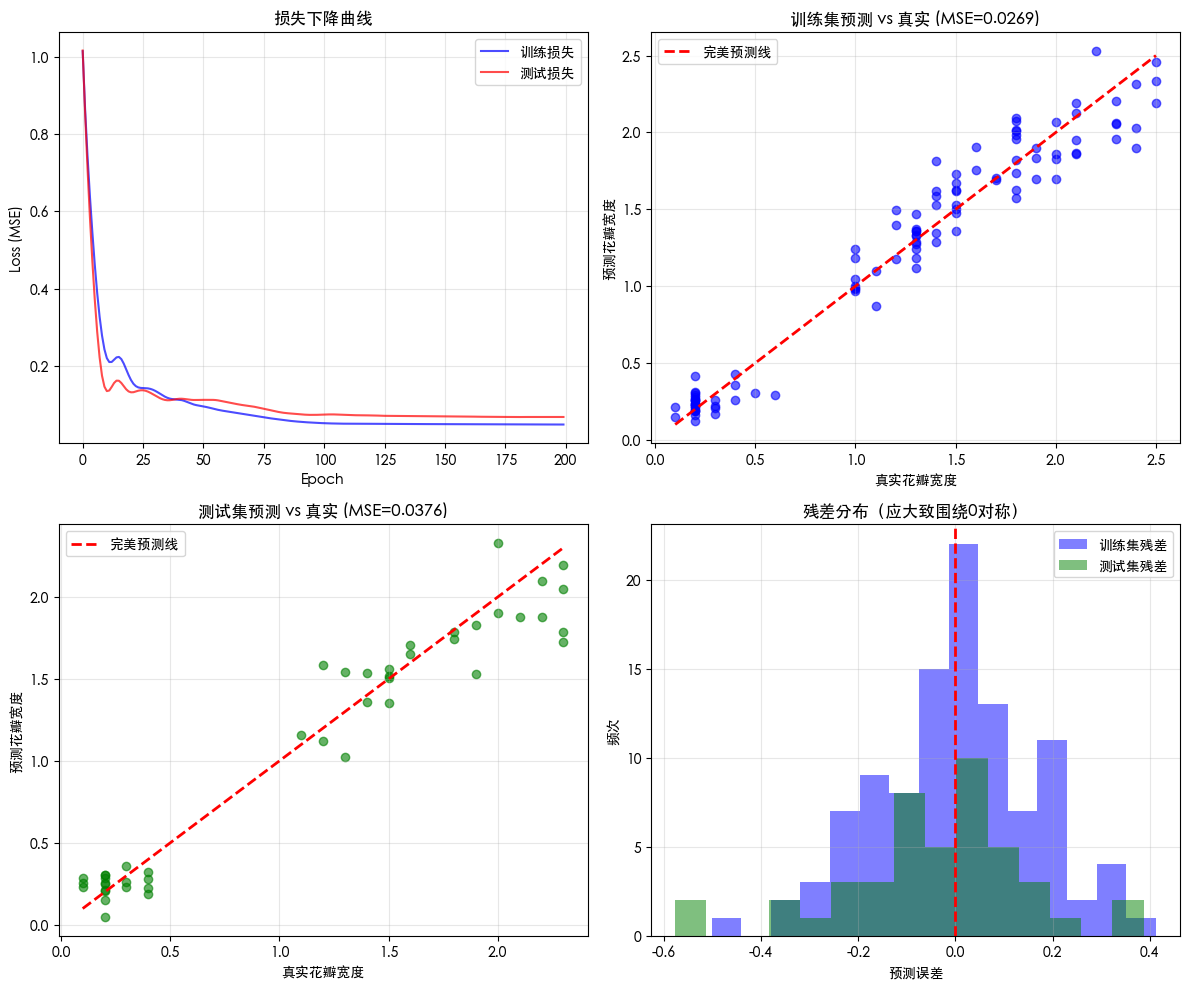

In [13]:
# ========== 6. 可视化结果 ==========
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 损失曲线
axes[0, 0].plot(train_losses, label='训练损失', color='blue', alpha=0.7)
axes[0, 0].plot(test_losses, label='测试损失', color='red', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].set_title('损失下降曲线')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 预测值 vs 真实值（训练集）
axes[0, 1].scatter(y_train_original, train_pred_original, alpha=0.6, color='blue')
axes[0, 1].plot([y_train_original.min(), y_train_original.max()], 
                [y_train_original.min(), y_train_original.max()], 
                'r--', linewidth=2, label='完美预测线')
axes[0, 1].set_xlabel('真实花瓣宽度')
axes[0, 1].set_ylabel('预测花瓣宽度')
axes[0, 1].set_title(f'训练集预测 vs 真实 (MSE={train_mse:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 预测值 vs 真实值（测试集）
axes[1, 0].scatter(y_test_original, test_pred_original, alpha=0.6, color='green')
axes[1, 0].plot([y_test_original.min(), y_test_original.max()], 
                [y_test_original.min(), y_test_original.max()], 
                'r--', linewidth=2, label='完美预测线')
axes[1, 0].set_xlabel('真实花瓣宽度')
axes[1, 0].set_ylabel('预测花瓣宽度')
axes[1, 0].set_title(f'测试集预测 vs 真实 (MSE={test_mse:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 残差分布
residuals_train = train_pred_original - y_train_original
residuals_test = test_pred_original - y_test_original
axes[1, 1].hist(residuals_train, bins=15, alpha=0.5, label='训练集残差', color='blue')
axes[1, 1].hist(residuals_test, bins=15, alpha=0.5, label='测试集残差', color='green')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('预测误差')
axes[1, 1].set_ylabel('频次')
axes[1, 1].set_title('残差分布（应大致围绕0对称）')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ========== 7. 预测示例 ==========
print("\n📊 预测示例（测试集前5个样本，原始尺度）:")
print("-" * 60)
for i in range(5):
    print(f"样本 {i+1}: 真实花瓣宽度 = {y_test_original[i]:.2f}, "
          f"预测花瓣宽度 = {test_pred_original[i]:.2f}, "
          f"误差 = {abs(test_pred_original[i] - y_test_original[i]):.3f}")


📊 预测示例（测试集前5个样本，原始尺度）:
------------------------------------------------------------
样本 1: 真实花瓣宽度 = 1.20, 预测花瓣宽度 = 1.59, 误差 = 0.388
样本 2: 真实花瓣宽度 = 0.30, 预测花瓣宽度 = 0.36, 误差 = 0.058
样本 3: 真实花瓣宽度 = 2.30, 预测花瓣宽度 = 2.05, 误差 = 0.252
样本 4: 真实花瓣宽度 = 1.50, 预测花瓣宽度 = 1.51, 误差 = 0.006
样本 5: 真实花瓣宽度 = 1.40, 预测花瓣宽度 = 1.53, 误差 = 0.134
